In [8]:
from gen_catalyst_design.discrete_space_diffusion.schedulers import ExponentialBetaScheduler, CosineScheduler, LinearBetaScheduler, LinearAlphaScheduler
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
import matplotlib as mpl
import matplotlib.patches as patches
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams["font.size"] = 16
mpl.rcParams["ytick.labelsize"] = 14
mpl.rcParams["xtick.labelsize"] = 14

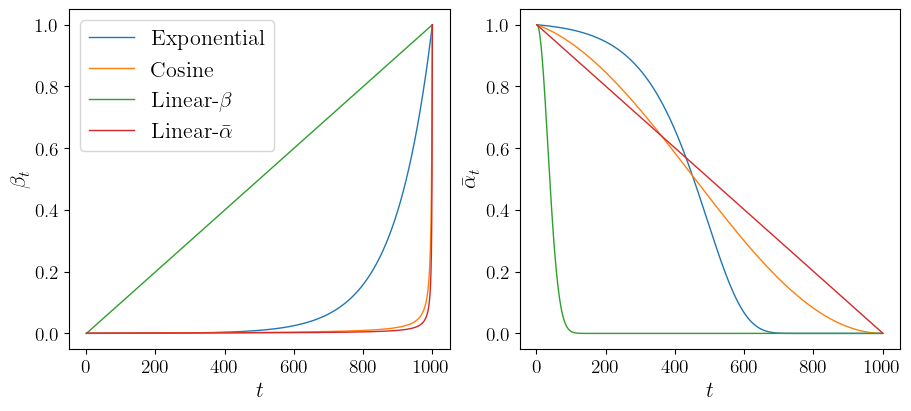

In [10]:
fig, axs = plt.subplots(1,2, figsize=(9,4), layout="constrained")
schedules = {
    "Exponential":ExponentialBetaScheduler, 
    "Cosine":CosineScheduler, 
    r"Linear-$\beta$":LinearBetaScheduler,
    r"Linear-$\bar{\alpha}$":LinearAlphaScheduler
}

for ax in axs:
    ax.set_xlabel(r"$t$")

axs[0].set_ylabel(r"$\beta_t$")
axs[1].set_ylabel(r"$\bar{\alpha}_t$")

beta_max = 1.0
beta_min = 1e-4
timesteps = torch.arange(1, 1001, 1)
for schedule_type in schedules:
    if schedule_type == "Cosine":
        scheduler = schedules[schedule_type](reg=0.1)
    else:
        scheduler = schedules[schedule_type](beta_min=beta_min, beta_max=beta_max)
    betas = scheduler(timesteps).numpy()
    alphas = 1.0-betas
    alpha_accum = np.array([np.prod(alphas[:i]) for i, _ in enumerate(alphas)])
    alpha_accum = alpha_accum.clip(min=1e-4, max=1.0-1e-4)
    snr_t = alpha_accum/(1.0-alpha_accum)
    axs[0].plot(timesteps.numpy(), betas, label=schedule_type, lw=1.0)
    axs[1].plot(timesteps.numpy(), alpha_accum, label=schedule_type, lw=1.0)
    #axs[2].plot(timesteps.numpy(), np.log(snr_t))
    axs[0].legend()
plt.savefig("schedules.pdf", bbox_inches='tight')